# Corpus Quality Analysis for Processed Chunk Files

This notebook scales chunk-quality testing from a single processed JSON file to the **entire processed corpus**.

## What it checks
- schema completeness
- chunk size / word count / duration sanity
- timestamp validity
- duplicate chunk IDs
- duplicate exact chunk text
- per-video chunk statistics
- corpus-level summary and a readiness decision

It is designed to work on all processed files matching:

`../data/processed/chunks_*.json`

In [44]:
import os
import json
import glob
import hashlib
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Configuration
Adjust thresholds here if needed.

In [45]:
PROCESSED_DIR = "../data/processed"
CHUNK_GLOB = "chunks_*.json"

# Quality thresholds
MIN_CHARS = 182
MAX_CHARS = 900
MIN_WORDS = 25
MAX_WORDS = 180
MIN_DURATION_SEC = 10
MAX_DURATION_SEC = 90

# Output reports
# REPORT_JSON = "quality_report_corpus.json"
# VIDEO_CSV = "quality_report_videos.csv"
# CHUNK_CSV = "quality_report_chunks.csv"
# ISSUES_CSV = "quality_report_issues.csv"

## Discover processed chunk files

In [46]:
chunk_files = sorted(
    path
    for path in glob.glob(os.path.join(PROCESSED_DIR, CHUNK_GLOB))
    if os.path.basename(path) != "processing_summary.json"
)

print(f"Found {len(chunk_files)} processed chunk file(s)")

chunk_files[:10]


Found 65 processed chunk file(s)


['../data/processed\\chunks_-CGxZ-qn4HA.json',
 '../data/processed\\chunks_04K0bLwCDdM.json',
 '../data/processed\\chunks_0VNIEfX0m4A.json',
 '../data/processed\\chunks_1YTKedLQOa0.json',
 '../data/processed\\chunks_21G7LA2DcGQ.json',
 '../data/processed\\chunks_6KqdCZHrR-w.json',
 '../data/processed\\chunks_6jQ4y0LK1kY.json',
 '../data/processed\\chunks_78K0pbvHzjM.json',
 '../data/processed\\chunks_7AsNUVVM0Sc.json',
 '../data/processed\\chunks_7E__zqy6xcw.json']

## Load all processed chunks into memory

In [47]:
all_chunks = []
file_level_summary = []

for path in chunk_files:
    with open(path, "r", encoding="utf-8") as f:
        chunks = json.load(f)

    file_video_id = chunks[0].get("video_id") if chunks else None

    file_level_summary.append({
        "file_path": path,
        "video_id": file_video_id,
        "chunk_count": len(chunks),
    })

    all_chunks.extend(chunks)

print(f"Loaded {len(all_chunks)} chunk(s) in total")
print(f"Loaded {len(file_level_summary)} file-level record(s)")

Loaded 1475 chunk(s) in total
Loaded 65 file-level record(s)


## Normalize chunk records for analysis

In [48]:
def safe_len_words(text):
    return len((text or "").split())

def md5_text(text):
    return hashlib.md5((text or "").strip().encode("utf-8")).hexdigest()

normalized_chunks = []

for chunk in all_chunks:
    metadata = chunk.get("metadata", {}) or {}
    text = chunk.get("text", "") or ""
    source_segments = chunk.get("source_segments")

    normalized_chunks.append({
        "chunk_id": chunk.get("chunk_id"),
        "video_id": chunk.get("video_id"),
        "video_title": chunk.get("video_title") or metadata.get("video_title"),
        "channel": chunk.get("channel") or metadata.get("channel"),
        "video_url": chunk.get("video_url") or metadata.get("video_url"),
        "chunk_index": chunk.get("chunk_index"),
        "total_chunks": chunk.get("total_chunks"),
        "text": text,
        "char_count": chunk.get("char_count", len(text)),
        "word_count": chunk.get("word_count", safe_len_words(text)),
        "start_time": chunk.get("start_time"),
        "end_time": chunk.get("end_time"),
        "start_time_str": chunk.get("start_time_str"),
        "end_time_str": chunk.get("end_time_str"),
        "duration_seconds": chunk.get("duration_seconds"),
        "source_segment_count": chunk.get(
            "source_segment_count",
            len(source_segments) if isinstance(source_segments, list) else None,
        ),
        "source_segments": source_segments,
        "transcript_language": chunk.get("transcript_language") or metadata.get("transcript_language"),
        "transcript_status": chunk.get("transcript_status") or metadata.get("transcript_status"),
        "video_duration": chunk.get("video_duration") or metadata.get("video_duration"),
        "upload_date": chunk.get("upload_date") or metadata.get("upload_date"),
        "view_count": chunk.get("view_count") or metadata.get("view_count"),
        "like_count": chunk.get("like_count") or metadata.get("like_count"),
        "comment_count": chunk.get("comment_count") or metadata.get("comment_count"),
        "description": chunk.get("description") or metadata.get("description"),
        "categories": chunk.get("categories") or metadata.get("categories"),
        "tags": chunk.get("tags") or metadata.get("tags"),
        "text_hash": md5_text(text),
    })

if pd is not None:
    df_chunks = pd.DataFrame(normalized_chunks)
    display(df_chunks.head())
else:
    df_chunks = None
    print(normalized_chunks[:2])


,chunk_id,video_id,video_title,channel,video_url,chunk_index,total_chunks,text,char_count,word_count,...,transcript_status,video_duration,upload_date,view_count,like_count,comment_count,description,categories,tags,text_hash
0,-CGxZ-qn4HA_chunk_0000,-CGxZ-qn4HA,Weighted integral & Weak formulation,Basics of Finite Element Analysis-I,https://www.youtube.com/watch?v=-CGxZ-qn4HA,0,25,"Hello, welcome to basics of finite element ana...",533,94,...,None,1689,20160201,44772,None,None,,[People & Blogs],"[Weighted, integral, weak, formulation]",5698f6042fd683bd89758d95ef27eeed
1,-CGxZ-qn4HA_chunk_0001,-CGxZ-qn4HA,Weighted integral & Weak formulation,Basics of Finite Element Analysis-I,https://www.youtube.com/watch?v=-CGxZ-qn4HA,1,25,. At this differential equation and this equat...,646,130,...,None,1689,20160201,44772,None,None,,[People & Blogs],"[Weighted, integral, weak, formulation]",b849ac16bc75da20de8eee72eb4daad7
2,-CGxZ-qn4HA_chunk_0002,-CGxZ-qn4HA,Weighted integral & Weak formulation,Basics of Finite Element Analysis-I,https://www.youtube.com/watch?v=-CGxZ-qn4HA,2,25,. And how do we figure out whether a boundary ...,594,112,...,None,1689,20160201,44772,None,None,,[People & Blogs],"[Weighted, integral, weak, formulation]",457d40f003385bd65914cd4db10a99f7
3,-CGxZ-qn4HA_chunk_0003,-CGxZ-qn4HA,Weighted integral & Weak formulation,Basics of Finite Element Analysis-I,https://www.youtube.com/watch?v=-CGxZ-qn4HA,3,25,. Whatever we know about the problem that is r...,688,129,...,None,1689,20160201,44772,None,None,,[People & Blogs],"[Weighted, integral, weak, formulation]",497aa59467f654121269dde4f41331ae
4,-CGxZ-qn4HA_chunk_0004,-CGxZ-qn4HA,Weighted integral & Weak formulation,Basics of Finite Element Analysis-I,https://www.youtube.com/watch?v=-CGxZ-qn4HA,4,25,. We will look at what types of problems this ...,244,48,...,None,1689,20160201,44772,None,None,,[People & Blogs],"[Weighted, integral, weak, formulation]",221b57f3cfa8f2cf3ec3a0ba19999a3b


Note there are none values and have to be cleaned before pinecone database upserting

## Validate schema and chunk quality

In [49]:
issues = []

def add_issue(level, issue_type, video_id=None, chunk_id=None, detail=None):
    issues.append({
        "level": level,
        "issue_type": issue_type,
        "video_id": video_id,
        "chunk_id": chunk_id,
        "detail": detail,
    })

for row in normalized_chunks:
    video_id = row.get("video_id")
    chunk_id = row.get("chunk_id")
    text = (row.get("text") or "").strip()

    char_count = row.get("char_count")
    if char_count is None:
        char_count = len(text)

    word_count = row.get("word_count")
    if word_count is None:
        word_count = len(text.split()) if text else 0

    st = row.get("start_time")
    et = row.get("end_time")

    duration_seconds = row.get("duration_seconds")
    if duration_seconds is None and st is not None and et is not None and et >= st:
        duration_seconds = et - st

    source_segments = row.get("source_segments")
    source_segment_count = row.get("source_segment_count")
    if source_segment_count is None and isinstance(source_segments, list):
        source_segment_count = len(source_segments)

    transcript_status = row.get("transcript_status")

    if not chunk_id:
        add_issue("error", "missing_chunk_id", video_id, chunk_id)

    if not video_id:
        add_issue("error", "missing_video_id", video_id, chunk_id)

    if not text:
        add_issue("error", "empty_text", video_id, chunk_id)

    if char_count is None:
        add_issue("error", "missing_char_count", video_id, chunk_id)
    else:
        if char_count < MIN_CHARS:
            add_issue("warning", "chunk_too_short_chars", video_id, chunk_id, char_count)
        if char_count > MAX_CHARS:
            add_issue("warning", "chunk_too_long_chars", video_id, chunk_id, char_count)

    if word_count is None:
        add_issue("error", "missing_word_count", video_id, chunk_id)
    else:
        if word_count < MIN_WORDS:
            add_issue("warning", "chunk_too_short_words", video_id, chunk_id, word_count)
        if word_count > MAX_WORDS:
            add_issue("warning", "chunk_too_long_words", video_id, chunk_id, word_count)

    if st is None or et is None:
        add_issue("error", "missing_time_range", video_id, chunk_id)
    elif et < st:
        add_issue("error", "invalid_time_range", video_id, chunk_id, f"{st} -> {et}")

    if duration_seconds is None:
        add_issue("warning", "missing_duration_seconds", video_id, chunk_id)
    else:
        if duration_seconds < MIN_DURATION_SEC:
            add_issue("warning", "chunk_too_short_duration", video_id, chunk_id, duration_seconds)
        if duration_seconds > MAX_DURATION_SEC:
            add_issue("warning", "chunk_too_long_duration", video_id, chunk_id, duration_seconds)

    if not isinstance(source_segments, list) or len(source_segments) == 0:
        add_issue("error", "missing_source_segments", video_id, chunk_id)

    if source_segment_count is None:
        add_issue("warning", "missing_source_segment_count", video_id, chunk_id)

    # Only validate transcript_status if present in the source schema
    if transcript_status not in [None, "ok"]:
        add_issue("warning", "non_ok_transcript_status", video_id, chunk_id, transcript_status)

print(f"Validation finished. Total issues found: {len(issues)}")
issues_df = pd.DataFrame(issues)
issues_df.head(20)

Validation finished. Total issues found: 202


,level,issue_type,video_id,chunk_id,detail
0,warning,chunk_too_long_duration,-CGxZ-qn4HA,-CGxZ-qn4HA_chunk_0001,112.15
1,warning,chunk_too_long_duration,-CGxZ-qn4HA,-CGxZ-qn4HA_chunk_0003,120.78
2,warning,chunk_too_long_duration,-CGxZ-qn4HA,-CGxZ-qn4HA_chunk_0005,105.85
3,warning,chunk_too_long_duration,-CGxZ-qn4HA,-CGxZ-qn4HA_chunk_0007,101.01
4,warning,chunk_too_long_duration,-CGxZ-qn4HA,-CGxZ-qn4HA_chunk_0009,112.10
5,warning,chunk_too_long_duration,-CGxZ-qn4HA,-CGxZ-qn4HA_chunk_0010,119.03
6,warning,chunk_too_long_duration,-CGxZ-qn4HA,-CGxZ-qn4HA_chunk_0011,103.82
7,warning,chunk_too_long_duration,-CGxZ-qn4HA,-CGxZ-qn4HA_chunk_0012,134.60
8,warning,chunk_too_long_duration,-CGxZ-qn4HA,-CGxZ-qn4HA_chunk_0013,118.24
9,warning,chunk_too_long_duration,-CGxZ-qn4HA,-CGxZ-qn4HA_chunk_0014,90.37


In [50]:
issues_df["issue_type"].value_counts()

issue_type
chunk_too_long_duration    185
chunk_too_short_chars       14
chunk_too_short_words        3
Name: count, dtype: int64

In [51]:
long_duration_df = pd.DataFrame([
    {
        "video_id": row.get("video_id"),
        "chunk_id": row.get("chunk_id"),
        "duration_seconds": row.get("duration_seconds"),
        "char_count": row.get("char_count"),
        "word_count": row.get("word_count"),
        "text_preview": (row.get("text") or "")[:250]
    }
    for row in normalized_chunks
    if row.get("duration_seconds") is not None and row.get("duration_seconds") > MAX_DURATION_SEC
])

long_duration_df = long_duration_df.sort_values(
    ["duration_seconds", "word_count", "char_count"],
    ascending=[False, True, True]
)

long_duration_df.head(20)

,video_id,chunk_id,duration_seconds,char_count,word_count,text_preview
69,TyJMwh7J98o,TyJMwh7J98o_chunk_0021,174.61,661,138,. Now du over dx if u is displacement the du o...
126,jQPwabwnBpg,jQPwabwnBpg_chunk_0024,160.94,655,121,. So this is one example where you apply a poi...
122,hJmM6CzFRW8,hJmM6CzFRW8_chunk_0017,154.32,509,92,". If there are no point loads, if there are on..."
72,Uv0o6Ni_5DY,Uv0o6Ni_5DY_chunk_0004,149.87,677,149,". v d/dx, okay. So I will just reorganize this..."
31,ADjrLtAaoGI,ADjrLtAaoGI_chunk_0009,149.58,614,133,. It is given in the differential equation whi...
44,C7gEY9sNXhg,C7gEY9sNXhg_chunk_0019,146.41,530,124,". So, so what we will do is so if I move this ..."
43,C7gEY9sNXhg,C7gEY9sNXhg_chunk_0018,145.23,580,131,. So in my definition of L I have this wa du o...
95,W7ndnuNrq78,W7ndnuNrq78_chunk_0022,145.18,681,130,. So very quickly we will cover these properti...
65,TyJMwh7J98o,TyJMwh7J98o_chunk_0012,144.77,683,162,. Similarly I get k12e if I do the same proces...
62,TyJMwh7J98o,TyJMwh7J98o_chunk_0005,143.90,631,116,. And the superscripts on all these guys is e ...


## Duplicate checks

In [52]:
if pd is not None and df_chunks is not None and not df_chunks.empty:
    dup_chunk_ids = df_chunks[df_chunks.duplicated(subset=["chunk_id"], keep=False)].copy()
    dup_text_hash = df_chunks[df_chunks.duplicated(subset=["text_hash"], keep=False)].copy()
    dup_text_exact = df_chunks[df_chunks.duplicated(subset=["text"], keep=False)].copy()
else:
    dup_chunk_ids = pd.DataFrame() if pd is not None else []
    dup_text_hash = pd.DataFrame() if pd is not None else []
    dup_text_exact = pd.DataFrame() if pd is not None else []

print("Duplicate chunk_ids:", 0 if pd is None or len(dup_chunk_ids) == 0 else dup_chunk_ids["chunk_id"].nunique())
print("Duplicate exact-text groups:", 0 if pd is None or len(dup_text_hash) == 0 else dup_text_hash["text_hash"].nunique())


Duplicate chunk_ids: 0
Duplicate exact-text groups: 0


## Per-video aggregation

In [53]:
if pd is not None and not df_chunks.empty:
    video_stats = (
        df_chunks.groupby("video_id", dropna=False)
        .agg(
            video_title=("video_title", "first"),
            channel=("channel", "first"),
            total_chunks=("chunk_id", "count"),
            total_words=("word_count", "sum"),
            total_chars=("char_count", "sum"),
            avg_chunk_words=("word_count", "mean"),
            avg_chunk_chars=("char_count", "mean"),
            min_chunk_chars=("char_count", "min"),
            max_chunk_chars=("char_count", "max"),
            min_start_time=("start_time", "min"),
            max_end_time=("end_time", "max"),
            avg_chunk_duration=("duration_seconds", "mean"),
            transcript_language=("transcript_language", "first"),
            transcript_status=("transcript_status", "first"),
            video_duration=("video_duration", "first"),
        )
        .reset_index()
    )

    display(video_stats.head())
else:
    video_stats = None
    print("No DataFrame available for per-video aggregation.")

,video_id,video_title,channel,total_chunks,total_words,total_chars,avg_chunk_words,avg_chunk_chars,min_chunk_chars,max_chunk_chars,min_start_time,max_end_time,avg_chunk_duration,transcript_language,transcript_status,video_duration
0,-CGxZ-qn4HA,Weighted integral & Weak formulation,Basics of Finite Element Analysis-I,25,2658,13542,106.320000,541.680000,244,700,13.70,1356.03,86.934000,en,None,1689
1,04K0bLwCDdM,The Incredible Properties of Composite Materials,The Efficient Engineer,37,3571,22296,96.513514,602.594595,391,694,0.18,1208.76,48.150270,en,None,1415
2,0VNIEfX0m4A,"Nodes, Elements & Shape Functions",Basics of Finite Element Analysis-I,27,2856,14724,105.777778,545.333333,252,691,13.78,1164.48,67.065926,en,None,1565
3,1YTKedLQOa0,Understanding Torsion,The Efficient Engineer,15,1785,9643,119.000000,642.866667,569,691,0.54,529.08,48.862000,en,None,615
4,21G7LA2DcGQ,Understanding Buckling,The Efficient Engineer,23,2355,14072,102.391304,611.826087,375,686,1.36,768.20,48.727826,en,None,888


## Issue summary

In [54]:
if pd is not None:
    df_issues = pd.DataFrame(issues)
    if not df_issues.empty:
        issue_summary = (
            df_issues.groupby(["level", "issue_type"])
            .size()
            .reset_index(name="count")
            .sort_values(["level", "count"], ascending=[True, False])
        )
        display(issue_summary)
    else:
        df_issues = pd.DataFrame(columns=["level", "issue_type", "video_id", "chunk_id", "detail"])
        print("No issues found.")
else:
    df_issues = None
    print(Counter(i["issue_type"] for i in issues))

,level,issue_type,count
0,warning,chunk_too_long_duration,185
1,warning,chunk_too_short_chars,14
2,warning,chunk_too_short_words,3


## Corpus-level summary and readiness decision

In [55]:
corpus_summary = {
    "generated_at": datetime.now().isoformat(),
    "processed_dir": PROCESSED_DIR,
    "files_found": len(chunk_files),
    "total_chunks": len(normalized_chunks),
    "total_videos": len(set(r["video_id"] for r in normalized_chunks if r["video_id"])),
    "total_words": int(sum(r["word_count"] or 0 for r in normalized_chunks)),
    "total_chars": int(sum(r["char_count"] or 0 for r in normalized_chunks)),
    "duplicate_chunk_ids": int(0 if pd is None else dup_chunk_ids["chunk_id"].nunique()),
    "duplicate_exact_text_groups": int(0 if pd is None else dup_text_hash["text_hash"].nunique()),
    "total_issues": len(issues),
    "issue_counts": dict(Counter(i["issue_type"] for i in issues)),
}

def rate_corpus(summary):
    total_chunks = summary["total_chunks"]
    dup_ids = summary["duplicate_chunk_ids"]
    total_issues = summary["total_issues"]

    if total_chunks < 50:
        return "needs_more_data"
    if dup_ids > 0:
        return "fix_duplicates_before_indexing"
    if total_issues > max(10, int(0.05 * total_chunks)):
        return "fix_quality_issues_before_indexing"
    return "ready_for_embedding_and_indexing"

decision = rate_corpus(corpus_summary)

print("Decision:", decision)
corpus_summary

Decision: fix_quality_issues_before_indexing


{'generated_at': '2026-03-09T12:19:22.926260',
 'processed_dir': '../data/processed',
 'files_found': 65,
 'total_chunks': 1475,
 'total_videos': 65,
 'total_words': 159894,
 'total_chars': 876106,
 'duplicate_chunk_ids': 0,
 'duplicate_exact_text_groups': 0,
 'total_issues': 202,
 'issue_counts': {'chunk_too_long_duration': 185,
  'chunk_too_short_chars': 14,
  'chunk_too_short_words': 3}}

## Save reports

In [56]:
# report_path = os.path.join(PROCESSED_DIR, REPORT_JSON)
# with open(report_path, "w", encoding="utf-8") as f:
#     json.dump(
#         {
#             "summary": corpus_summary,
#             "decision": decision,
#             "issues": issues,
#         },
#         f,
#         indent=2,
#         ensure_ascii=False,
#     )

# print("Saved JSON report:", report_path)

# if pd is not None:
#     if video_stats is not None:
#         video_stats.to_csv(os.path.join(PROCESSED_DIR, VIDEO_CSV), index=False)
#     df_chunks.to_csv(os.path.join(PROCESSED_DIR, CHUNK_CSV), index=False)
#     pd.DataFrame(issues).to_csv(os.path.join(PROCESSED_DIR, ISSUES_CSV), index=False)
#     print("Saved CSV reports")

## Optional charts

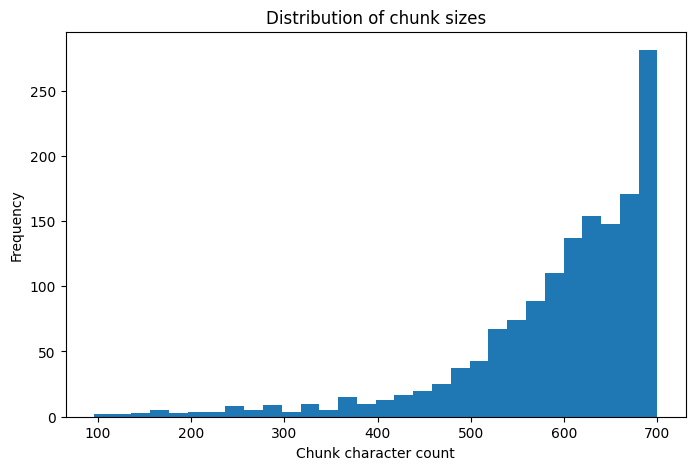

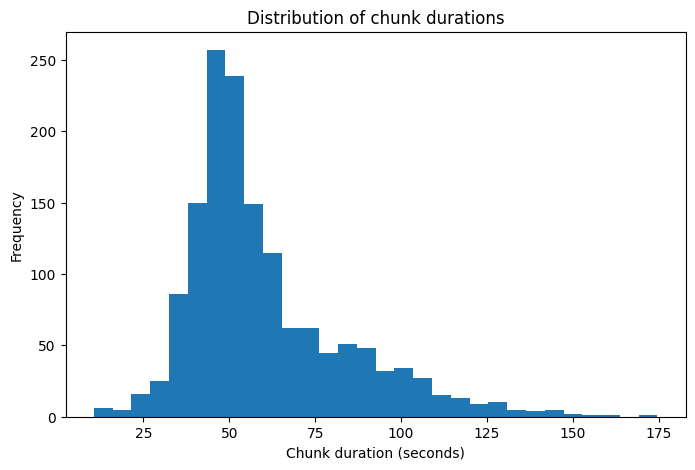

In [57]:
if plt is not None and pd is not None and not df_chunks.empty:
    plt.figure(figsize=(8, 5))
    plt.hist(df_chunks["char_count"].dropna(), bins=30)
    plt.xlabel("Chunk character count")
    plt.ylabel("Frequency")
    plt.title("Distribution of chunk sizes")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.hist(df_chunks["duration_seconds"].dropna(), bins=30)
    plt.xlabel("Chunk duration (seconds)")
    plt.ylabel("Frequency")
    plt.title("Distribution of chunk durations")
    plt.show()
else:
    print("matplotlib or pandas not available, or no data to plot.")

## Inspect duplicates if any

In [58]:
if pd is not None:
    print("Duplicate chunk IDs:")
    if dup_chunk_ids.empty:
        print("None found.")
    else:
        display(dup_chunk_ids[["chunk_id", "video_id", "video_title", "chunk_index"]].head(20))

    print("\nDuplicate exact chunk text:")
    if dup_text_exact.empty:
        print("None found.")
    else:
        display(dup_text_exact[["video_id", "video_title", "chunk_id", "chunk_index", "text"]].head(20))


Duplicate chunk IDs:
None found.

Duplicate exact chunk text:
None found.


## Inspect problematic videos

In [59]:
if pd is not None and df_issues is not None and not df_issues.empty:
    issues_per_video = (
        df_issues.groupby("video_id")
        .size()
        .reset_index(name="issue_count")
        .sort_values("issue_count", ascending=False)
    )
    display(issues_per_video.head(20))
else:
    print("No issue table available.")

,video_id,issue_count
0,-CGxZ-qn4HA,13
30,rFztdZ7-b2M,12
27,p9eHKmnN6Yo,12
12,TyJMwh7J98o,12
17,W7ndnuNrq78,11
29,pOEjUkTecAM,11
6,C7gEY9sNXhg,11
4,ADjrLtAaoGI,10
26,n3pIc8kVFjU,9
18,Ytm7V3fmdR8,9


In [60]:
print("\n" + "=" * 80)
print("RAG QUALITY ASSESSMENT")
print("=" * 80)

if pd is None or df_chunks is None or df_chunks.empty:
    print("\nNo chunk data available for benchmark assessment.")
else:
    # Compute corpus stats from df_chunks
    total_chunks = len(df_chunks)
    total_words = int(df_chunks["word_count"].sum())
    chunk_sizes = df_chunks["char_count"].dropna().tolist()
    total_videos = df_chunks["video_id"].nunique()

    # Industry-style benchmarks
    benchmarks = {
        "min_chunks": 50,
        "good_chunks": 100,
        "excellent_chunks": 200,
        "min_words": 10000,
        "good_words": 20000,
        "excellent_words": 40000,
        "min_chunk_size": 200,
        "max_chunk_size": 1500,
        "good_videos": 10,
        "excellent_videos": 25,
    }

    print("\n📊 Your Dataset vs Benchmarks:\n")

    def assess(value, min_val, good_val, name, excellent_val=None):
        if excellent_val is not None and value >= excellent_val:
            status = "✅ EXCELLENT"
        elif value >= good_val:
            status = "🟢 STRONG"
        elif value >= min_val:
            status = "🟡 GOOD"
        else:
            status = "⚠️ NEEDS MORE"

        print(f"  {name}: {value:,} {status}")
        if excellent_val is not None:
            print(f"    Benchmark: Min={min_val:,}, Good={good_val:,}, Excellent={excellent_val:,}")
        else:
            print(f"    Benchmark: Min={min_val:,}, Good={good_val:,}")

        return value >= min_val

    checks = []
    checks.append(
        assess(
            total_chunks,
            benchmarks["min_chunks"],
            benchmarks["good_chunks"],
            "Total Chunks",
            benchmarks["excellent_chunks"],
        )
    )

    checks.append(
        assess(
            total_words,
            benchmarks["min_words"],
            benchmarks["good_words"],
            "Total Words",
            benchmarks["excellent_words"],
        )
    )

    checks.append(
        assess(
            total_videos,
            5,
            benchmarks["good_videos"],
            "Total Videos",
            benchmarks["excellent_videos"],
        )
    )

    avg_chunk_size = float(np.mean(chunk_sizes)) if chunk_sizes else 0
    print(f"\n  Avg Chunk Size: {avg_chunk_size:.0f} chars", end=" ")
    if benchmarks["min_chunk_size"] <= avg_chunk_size <= benchmarks["max_chunk_size"]:
        print("✅ OPTIMAL")
        checks.append(True)
    else:
        print("⚠️ SUBOPTIMAL")
        checks.append(False)

    print(f"    Optimal Range: {benchmarks['min_chunk_size']}-{benchmarks['max_chunk_size']} chars")

    # Additional useful corpus stats
    median_chunk_size = float(np.median(chunk_sizes)) if chunk_sizes else 0
    chunks_per_video = df_chunks.groupby("video_id").size()
    avg_chunks_per_video = float(chunks_per_video.mean()) if len(chunks_per_video) else 0

    print(f"\n  Median Chunk Size: {median_chunk_size:.0f} chars")
    print(f"  Avg Chunks per Video: {avg_chunks_per_video:.1f}")
    print(f"  Min Chunks in a Video: {int(chunks_per_video.min()) if len(chunks_per_video) else 0}")
    print(f"  Max Chunks in a Video: {int(chunks_per_video.max()) if len(chunks_per_video) else 0}")

    # Issue-aware adjustment
    issue_penalty = 0
    if 'df_issues' in globals() and df_issues is not None and not df_issues.empty:
        error_count = int((df_issues["level"] == "error").sum())
        warning_count = int((df_issues["level"] == "warning").sum())
        print(f"\n  Errors Found: {error_count}")
        print(f"  Warnings Found: {warning_count}")

        if error_count > 0:
            issue_penalty += 2
        elif warning_count > max(10, total_chunks * 0.05):
            issue_penalty += 1

    print("\n" + "=" * 80)
    score = sum(checks) - issue_penalty

    if score >= 4:
        print("✅ OVERALL: Your dataset is GOOD for RAG")
        print("   You have sufficient chunked content for a solid chatbot knowledge base.")
    elif score >= 2:
        print("🟡 OVERALL: Your dataset is ACCEPTABLE for RAG")
        print("   It should work, but adding more videos or improving chunk quality would help.")
    else:
        print("⚠️ OVERALL: Your dataset NEEDS MORE WORK")
        print("   Improve chunk quality and/or add more source material before indexing.")
    print("=" * 80)



RAG QUALITY ASSESSMENT

📊 Your Dataset vs Benchmarks:

  Total Chunks: 1,475 ✅ EXCELLENT
    Benchmark: Min=50, Good=100, Excellent=200
  Total Words: 159,894 ✅ EXCELLENT
    Benchmark: Min=10,000, Good=20,000, Excellent=40,000
  Total Videos: 65 ✅ EXCELLENT
    Benchmark: Min=5, Good=10, Excellent=25

  Avg Chunk Size: 594 chars ✅ OPTIMAL
    Optimal Range: 200-1500 chars

  Median Chunk Size: 622 chars
  Avg Chunks per Video: 22.7
  Min Chunks in a Video: 4
  Max Chunks in a Video: 40

  Errors Found: 0
  Warnings Found: 202

🟡 OVERALL: Your dataset is ACCEPTABLE for RAG
   It should work, but adding more videos or improving chunk quality would help.


## Recommendation

Use this notebook **before Pinecone indexing** as a gating step.

Then, after Pinecone is populated, run a separate **retrieval QA notebook** to test:
- query relevance
- timestamped answerability
- metadata filters
- top-k duplicate retrieval